In [17]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import sys
import os

sys.path.append(os.path.abspath('..'))

from src.utils import load_full_config
from src.model import SimpleTransformer
from src.dataset import generate_ou_process

In [18]:
cfg = load_full_config()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = SimpleTransformer(**cfg['architecture'])
model_path = os.path.join('..', cfg['paths']['save_dir'], cfg['paths']['mean_pred_model_name'])

if os.path.exists(model_path):
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.to(device)
    model.eval()
    print(f"Loaded model from {model_path}")
else:
    raise FileNotFoundError(f"Model not found at {model_path}. Train with mode 2 first.")

Loaded model from ../experiments/model_mean_pred.pth


In [19]:
multi_cfg = cfg['multi_mean']
num_trajectories = 200
mean_min = multi_cfg['mean_min']
mean_max = multi_cfg['mean_max']
random_means = np.random.uniform(mean_min, mean_max, num_trajectories)

all_trajectories = []
all_actual_means = []

for mu in random_means:
    traj = generate_ou_process(
        batch_size=1,
        time_steps=cfg['generation']['total_time_steps'],
        theta=cfg['physics']['theta'],
        mu=float(mu),
        sigma=cfg['physics']['sigma'],
        dt=cfg['physics']['dt']
    )
    all_trajectories.append(traj)
    all_actual_means.append(mu)

all_trajectories = torch.cat(all_trajectories, dim=0)
all_actual_means = np.array(all_actual_means)

print(f"Generated {len(all_trajectories)} trajectories with random means in [{mean_min}, {mean_max}]")

Generated 200 trajectories with random means in [-1.5, 1.5]


In [20]:
predicted_means = []

with torch.no_grad():
    for i in range(len(all_trajectories)):
        traj = all_trajectories[i:i+1].to(device)
        pred, _ = model(traj)
        pred_mean = pred[:, -1, :].squeeze().cpu().item()
        predicted_means.append(pred_mean)

predicted_means = np.array(predicted_means)

print(f"Predicted {len(predicted_means)} means")

Predicted 200 means


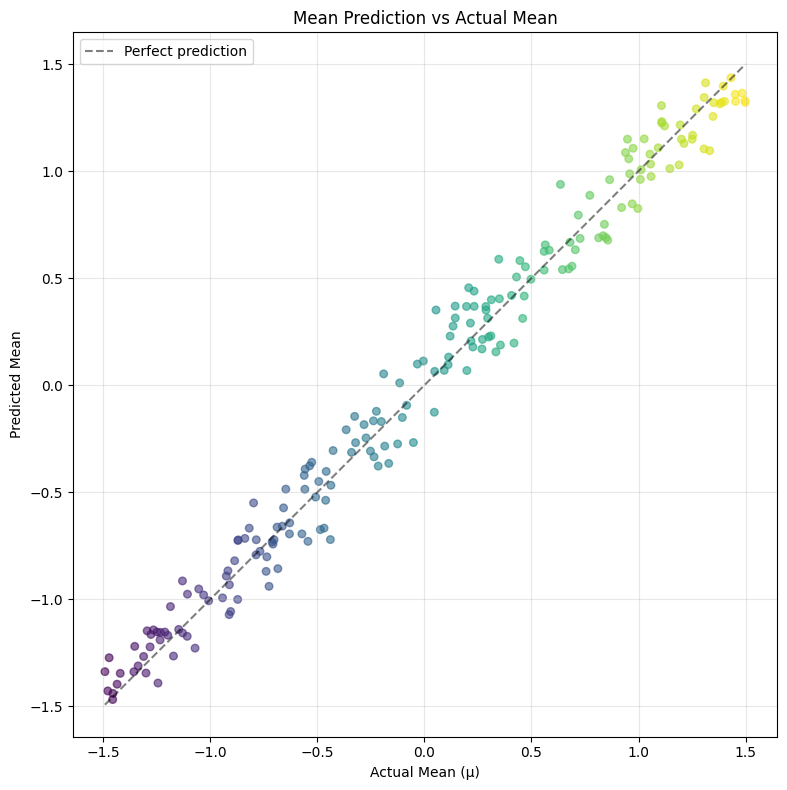

In [21]:
fig, ax = plt.subplots(figsize=(8, 8))

ax.scatter(all_actual_means, predicted_means, alpha=0.6, s=30, c=all_actual_means, cmap='viridis')

min_val = min(all_actual_means.min(), predicted_means.min())
max_val = max(all_actual_means.max(), predicted_means.max())
ax.plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.5, label='Perfect prediction')

ax.set_xlabel('Actual Mean (μ)')
ax.set_ylabel('Predicted Mean')
ax.set_title('Mean Prediction vs Actual Mean')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

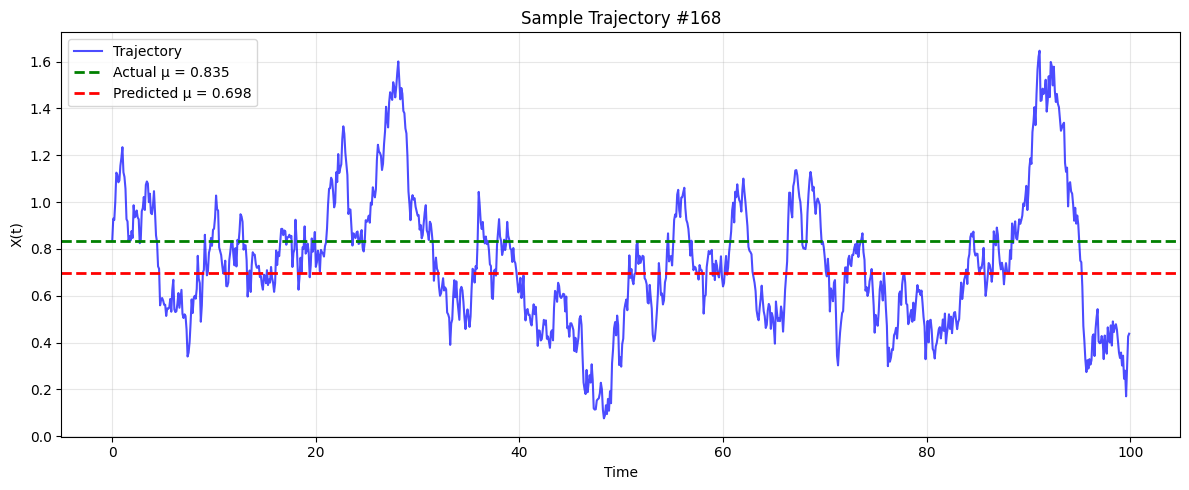

In [35]:
idx = np.random.randint(0, len(all_trajectories))
traj = all_trajectories[idx].squeeze().cpu().numpy()
actual_mean = all_actual_means[idx]
pred_mean = predicted_means[idx]

timestamps = np.arange(len(traj)) * cfg['physics']['dt']

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(timestamps, traj, 'b-', alpha=0.7, label='Trajectory')
ax.axhline(y=actual_mean, color='green', linestyle='--', linewidth=2, label=f'Actual μ = {actual_mean:.3f}')
ax.axhline(y=pred_mean, color='red', linestyle='--', linewidth=2, label=f'Predicted μ = {pred_mean:.3f}')

ax.set_xlabel('Time')
ax.set_ylabel('X(t)')
ax.set_title(f'Sample Trajectory #{idx}')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()